In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mofapy2.run.entry_point import entry_point
from sklearn.preprocessing import StandardScaler
import os
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

DATA LOADING

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

views = {
    "circRNA": None,
    "miRNA": None,
    "mRNA": None,
    "phosphoproteome": None,
    "proteome": None,
    "SCNA": None
}


# Ricarica ogni DataFrame dal CSV
for name in views.keys():
    views[name] = pd.read_csv(f"PDAC_DATA_PREPROCESSED/{name}.csv",index_col=0)

clinical_df = pd.read_csv("PDAC_DATA_PREPROCESSED/clinical.csv",index_col=0)


MOFA

In [8]:
# CONFIGURAZIONE DI MOFA 

data_for_mofa = [] # Lista di matrici
view_names = []  # Lista dei nomi delle viste

print("Creazione matrici per MOFA...")

for view_name, view in views.items():
    # Prendi i valori della vista come numpy array
    matrix = view.values
    
    # Stampa informazioni
    print(f"Vista '{view_name}' ({matrix.shape}): {matrix.shape[1]} features trovate.")
    
    # MOFA vuole le dimensioni (N_samples, N_features)
    data_for_mofa.append([matrix])  # NOTA: MOFA spesso richiede lista di matrici per ogni vista
    view_names.append(view_name)

# Inizializzazione
ent = entry_point()

# Data Options
# Passiamo la lista di matrici. 
ent.set_data_matrix(
    data=data_for_mofa, 
    likelihoods=["gaussian"]*(len(view_names)),
    #likelihoods=["gaussian"]*2+["poisson"]*2+["gaussian"]*(len(view_names)-4),
    views_names=view_names
)
#ent.set_data_options(scale_views=True, center_groups=True)     # QUI': Già standardizzate, non serve

# Model Options
# num_factors: Quanti "super-valori" vuoi trovare?
ent.set_model_options(factors=15, spikeslab_weights=True, ard_factors=True) #15

# Training Options
# max_iter: numero di cicli di apprendimento
ent.set_train_options(iter=1000, convergence_mode='fast', verbose=False, dropR2 = 0.001, seed = 42)

Creazione matrici per MOFA...
Vista 'circRNA' ((137, 3167)): 3167 features trovate.
Vista 'miRNA' ((137, 367)): 367 features trovate.
Vista 'mRNA' ((137, 25954)): 25954 features trovate.
Vista 'phosphoproteome' ((137, 4582)): 4582 features trovate.
Vista 'proteome' ((137, 7769)): 7769 features trovate.
Vista 'SCNA' ((137, 19891)): 19891 features trovate.

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Features names not provided, us

In [9]:
# ESECUZIONE DI MOFA

ent.build()

# 5. RUN
ent.run()
ent.save(r".\model\mofa_model.hdf5", save_data=True)

print("Training completato con successo!")

# Salviamo il modello in un oggetto per usarlo dopo
model = ent.model



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -87606748.49 

Iteration 1: time=5.71, ELBO=-13181042.52, deltaELBO=74425705.962 (84.95430689%), Factors=14
Iteration 2: time=4.53, ELBO=-12074905.15, deltaELBO=1106137.379 (1.26261663%), Factors=13
Iteration 3: time=3.98, ELBO=-11902330.35, deltaELBO=172574.791 (0.19698801%), Factors=13
Iteration 4: time=3.97, ELBO=-11791663.61, deltaELBO=110666.744 (0.12632217%), Factors=13
Iteration 5: time=4.11, ELBO=-11696894.70, deltaELBO=94768.912 (0.10817536%), Factors=13
Iteration 6: time=3.90, ELBO=-11622078.35, deltaELBO=74816.348 (0.08540021%), Factors=13
Iteration 7: time=4.09, ELBO=-11568131.55, deltaELBO=53946.802 (0.06157836%), Factors=13
Iteration 8: time=3.92, ELBO=-11531136.70, deltaELBO=36994.853 (0.04222831%), Factors=13
Iteration 9: time=3.63, ELBO=-11505631.31, deltaELBO=25505.390 (0.02911350%), Factors=13
Iteration 10: time=3.49, ELBO=-114

Tipo restituito: <class 'list'>
Numero di viste trovate: 6
Varianza totale spiegata per vista:
 circRNA            0.107416
miRNA              0.517817
mRNA               0.368346
phosphoproteome    0.312109
proteome           0.314992
SCNA               0.411544
dtype: float64


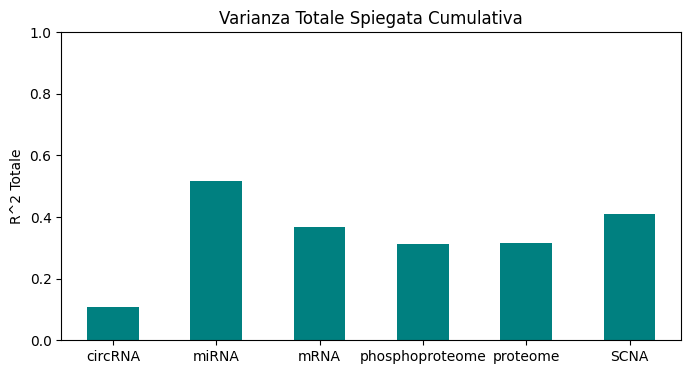

In [10]:
# 1. Calcola la varianza (che ritorna una lista)
r2_list = model.calculate_variance_explained()

# Verifica rapida
print(f"Tipo restituito: {type(r2_list)}")
print(f"Numero di viste trovate: {len(r2_list[0])}")

r2_data = dict()
for i, view_name in enumerate(view_names):
    r2_data[view_name] = r2_list[0][i]

r2_df = pd.DataFrame(r2_data).T
r2_df.columns = [f"LF {i+1}" for i in range(r2_df.shape[1])]
# print(r2_df)
r2_total = r2_df.sum(axis=1)
print("Varianza totale spiegata per vista:\n", r2_total)

plt.figure(figsize=(8, 4))
r2_total.plot(kind='bar', color='teal')
plt.title("Varianza Totale Spiegata Cumulativa")
plt.ylabel("R^2 Totale")
plt.ylim(0, 1) # O il massimo teorico se superiore
plt.xticks(rotation=0, ha='center')
plt.savefig('../img/MOFA_var_spiegata.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# VISUALIZZA FATTORI LATENTI (matrice Z)

# 1. Estraiamo il dizionario dei Fattori Latenti (Z)
z_dict = ent.model.getExpectations()["Z"]

# Stampiamo le chiavi per vedere come MOFA ha chiamato il gruppo
print(f"Nomi dei gruppi trovati nel modello: {list(z_dict.keys())}")

# Invece di scrivere [0], prendiamo dinamicamente la prima chiave disponibile
group_name = list(z_dict.keys())[0] 
Z_matrix = z_dict[group_name]

print(f"Matrice Z estratta per il gruppo: '{group_name}'")
print(f"Dimensioni matrice: {Z_matrix.shape}")

# 2. Creiamo un DataFrame pandas
# Usiamo l'indice di df_clean per riassociare i nomi (SampleID) ai punti
factor_columns = [f"Factor{i+1}" for i in range(Z_matrix.shape[1])]

df_factors = pd.DataFrame(
    Z_matrix, 
    index=clinical_df.index,
    columns=factor_columns
)

df_factors.to_excel('./exported_data/MOFA_factors.xlsx', sheet_name='Factors')
df_factors.head()

Nomi dei gruppi trovati nel modello: ['E', 'E2']
Matrice Z estratta per il gruppo: 'E'
Dimensioni matrice: (137, 13)


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13
case_id,,,,,,,,,,,,,
C3L-00017,3.772759,-0.024180,-0.039678,1.375110,-0.551716,-0.176812,0.165779,-0.112902,1.244698,-0.197673,-0.659694,0.129649,-0.200652
C3L-00102,1.362362,-0.283709,0.847602,3.748061,-1.124642,0.037608,0.609494,-0.072042,-0.812959,-0.028058,0.364193,0.017682,0.086342
C3L-00189,2.768533,-1.336807,0.614068,-0.476359,1.154339,0.115143,0.248770,-0.084077,-0.418311,-0.135630,-0.080273,-0.006149,-0.138083
C3L-00277,1.526149,1.867423,1.530237,1.292304,-0.362401,-0.072971,-0.124941,-0.226568,0.509663,-0.446523,-0.404787,-0.060446,-0.109199
C3L-00401,3.035923,0.111856,0.122542,0.457961,-0.341562,-0.069621,0.115786,-0.087630,0.447297,-0.052590,-0.033771,-0.002028,-0.153106


In [12]:
# ESTRAZIONE DEI PESI (matrice W, una per ogni vista)

# Recuperiamo i pesi (W) dal modello
w_dict = ent.model.getExpectations()["W"]

# Dizionario per salvare i dataframe dei pesi per ogni vista
weights_per_view = {}

for i, view_name in enumerate(view_names):
    # Pesi della vista corrente
    W_view = w_dict[i]       # dizionario con chiave 'E'
    W_matrix = W_view['E']   # matrice dei pesi
    print(f"Vista {view_name}, shape matrice E: {W_matrix.shape}")
    
    # Nomi delle feature della vista normalizzata
    cols = views[view_name].columns
    
    # Crea DataFrame dei pesi per questa vista
    df_w_view = pd.DataFrame(W_matrix, index=cols, columns=factor_columns)
    
    # Salva nel dizionario con chiave = nome vista
    weights_per_view[view_name] = df_w_view

# Ora weights_per_view["mRNA"], weights_per_view["proteome"], ecc. contengono i pesi
for view_name, df_w in weights_per_view.items():
    print(f"{view_name}: {df_w.shape} (righe=feature, colonne=factors)")



Vista circRNA, shape matrice E: (3167, 13)
Vista miRNA, shape matrice E: (367, 13)
Vista mRNA, shape matrice E: (25954, 13)
Vista phosphoproteome, shape matrice E: (4582, 13)
Vista proteome, shape matrice E: (7769, 13)
Vista SCNA, shape matrice E: (19891, 13)
circRNA: (3167, 13) (righe=feature, colonne=factors)
miRNA: (367, 13) (righe=feature, colonne=factors)
mRNA: (25954, 13) (righe=feature, colonne=factors)
phosphoproteome: (4582, 13) (righe=feature, colonne=factors)
proteome: (7769, 13) (righe=feature, colonne=factors)
SCNA: (19891, 13) (righe=feature, colonne=factors)


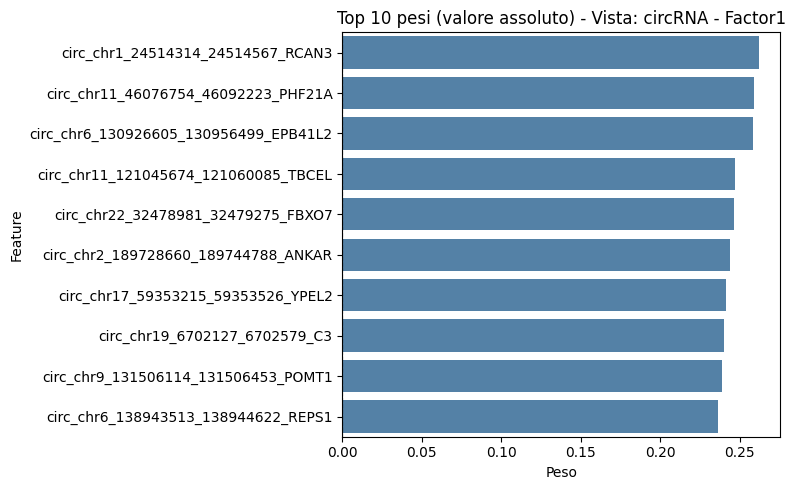

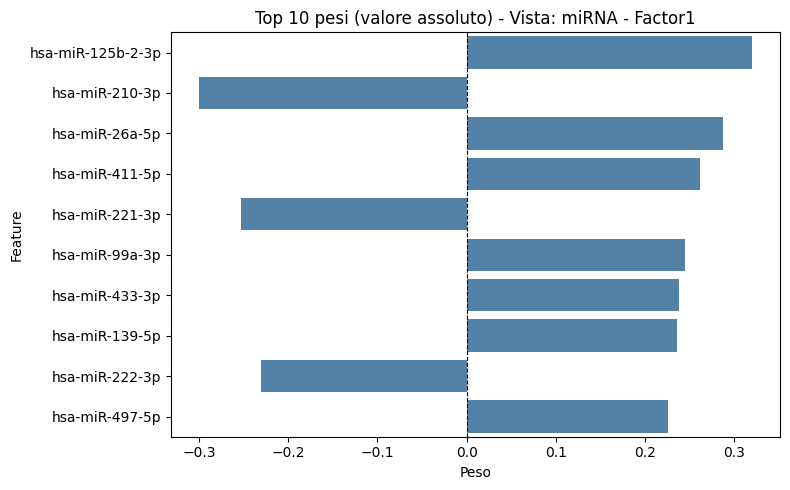

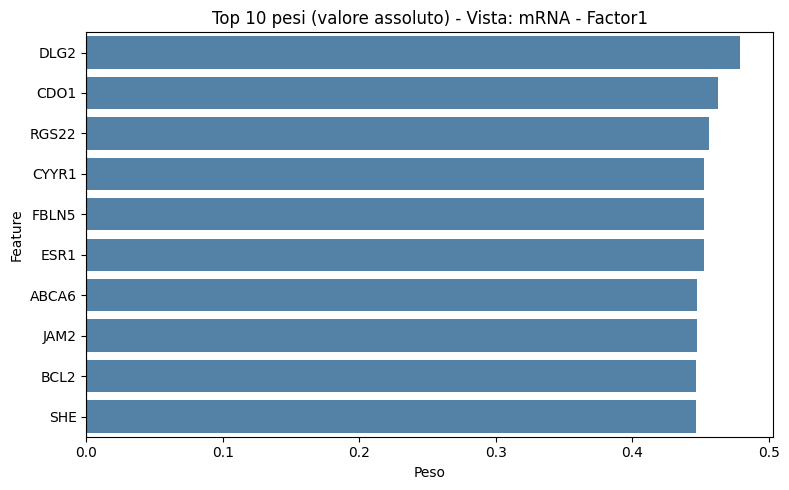

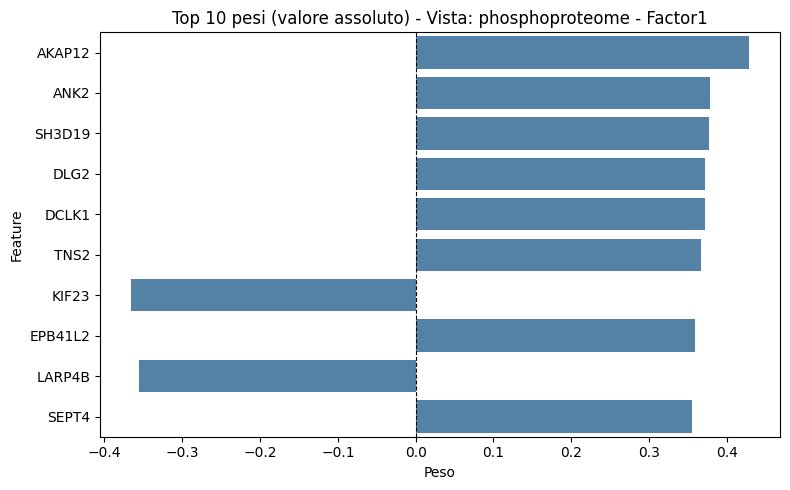

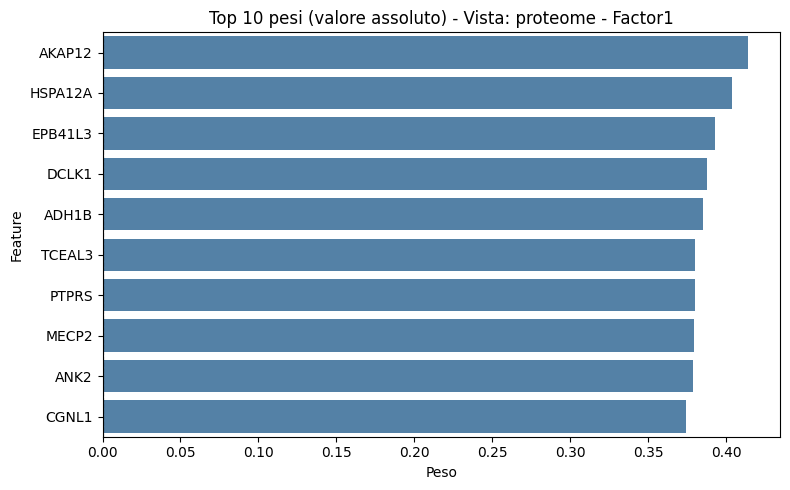

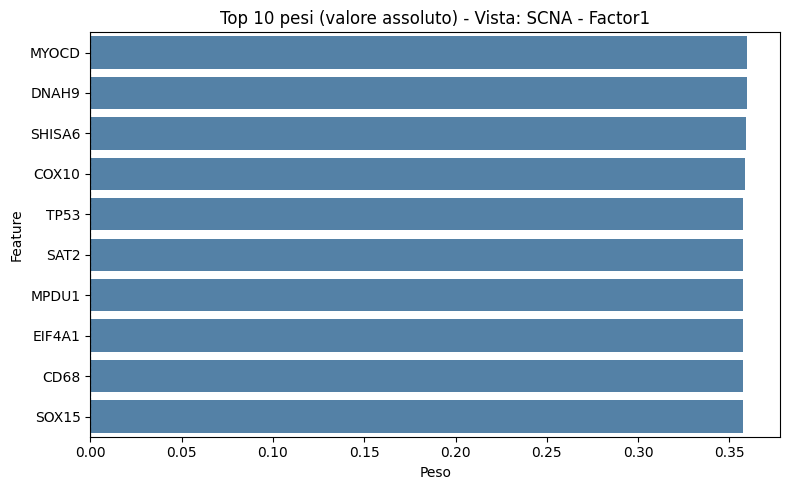

In [13]:
# VISUALIZZAZIONE DEI PESI PER OGNI VISTA E FATTORE
# Viene considerato solo il fattore 1 della matrice W, e vengono filtrate le 10 feature con il peso maggiore. Il valore di questi pesi viene poi rappresentato in un grafico.
factor1 = weights_per_view[list(weights_per_view.keys())[0]].columns[0]  # Prende solo il primo fattore

for view_name, df_w in weights_per_view.items():
    # Seleziona le top 10 feature per valore assoluto (ma conserva il segno)
    top_features = df_w[factor1].abs().sort_values(ascending=False).head(10)
    top_features = df_w.loc[top_features.index, factor1]  # Ripristina il segno originale

    # Grafico a barre orizzontali
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_features.values, y=top_features.index, color="steelblue")
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)  # Linea verticale a x=0
    plt.title(f"Top 10 pesi (valore assoluto) - Vista: {view_name} - {factor1}")
    plt.xlabel("Peso")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(f'../img/MOFA_top10_weights_{view_name}-{factor1}.png', dpi=300, bbox_inches='tight')
    plt.show()



=== Heatmap dei pesi: circRNA ===


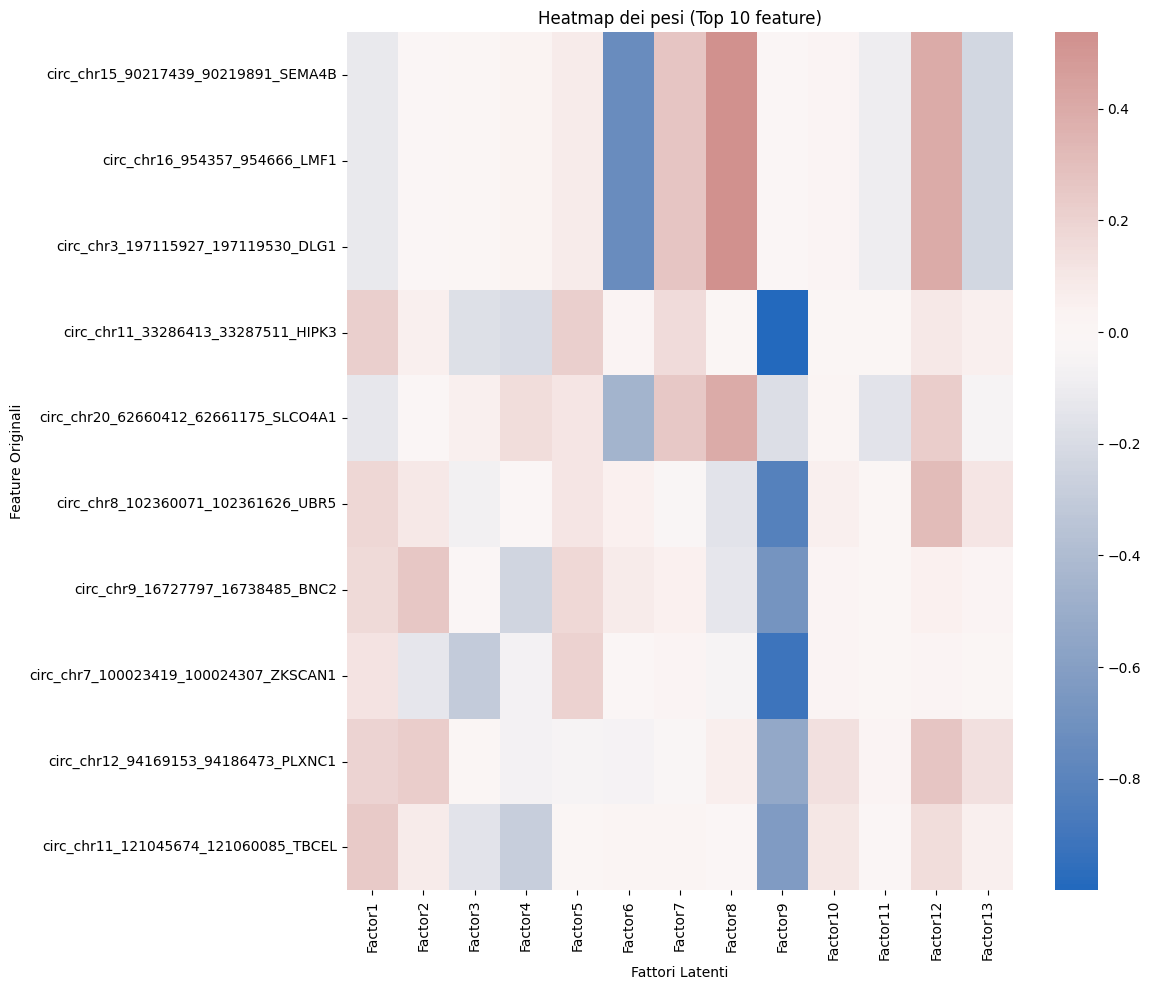


=== Heatmap dei pesi: miRNA ===


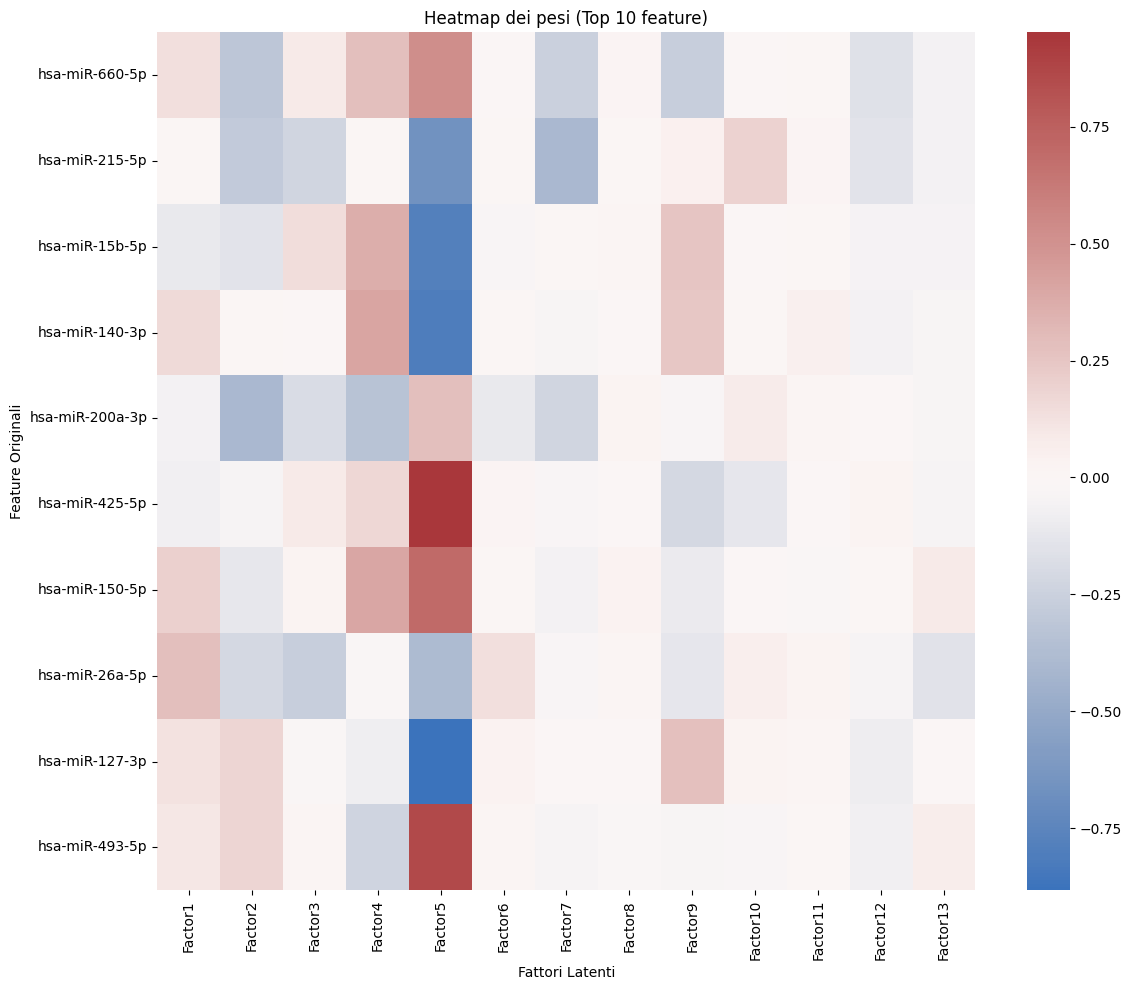


=== Heatmap dei pesi: mRNA ===


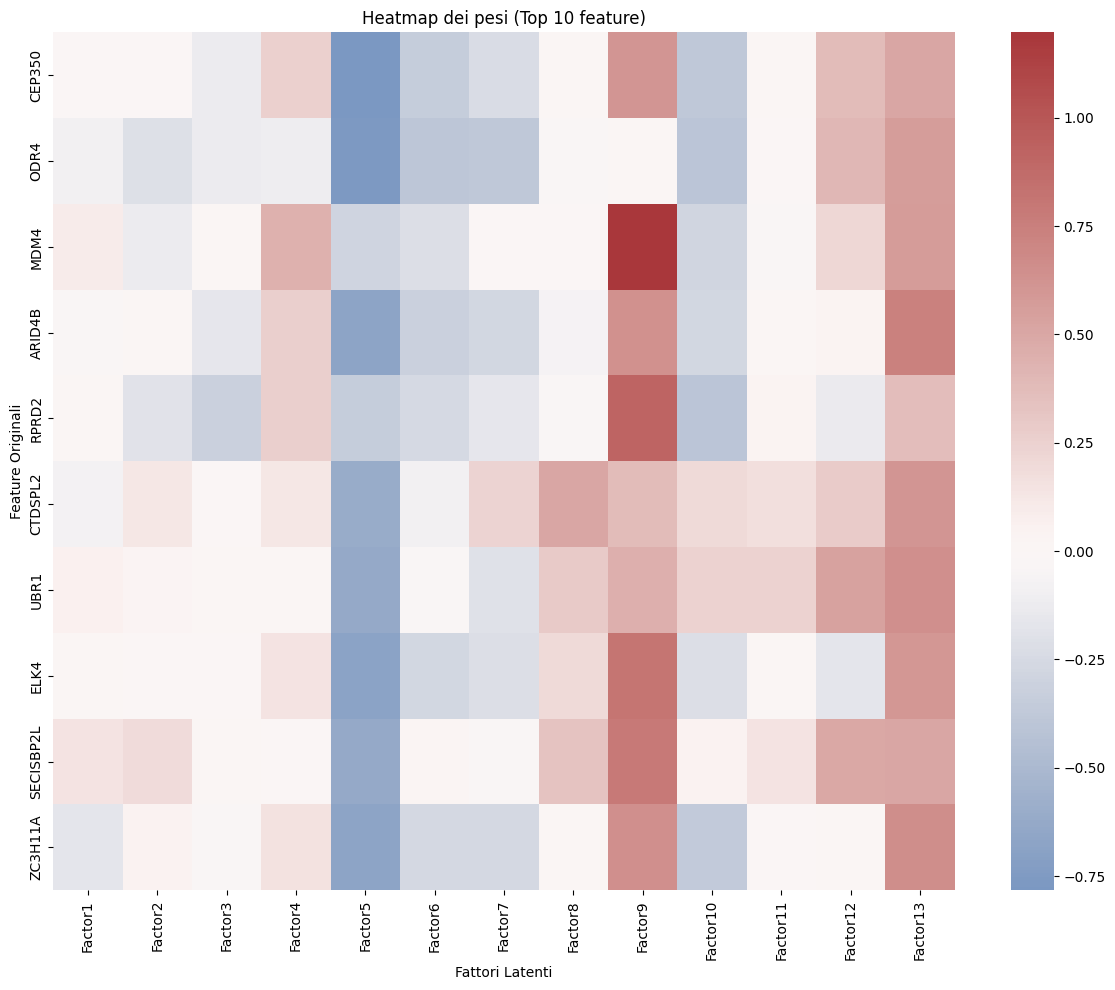


=== Heatmap dei pesi: phosphoproteome ===


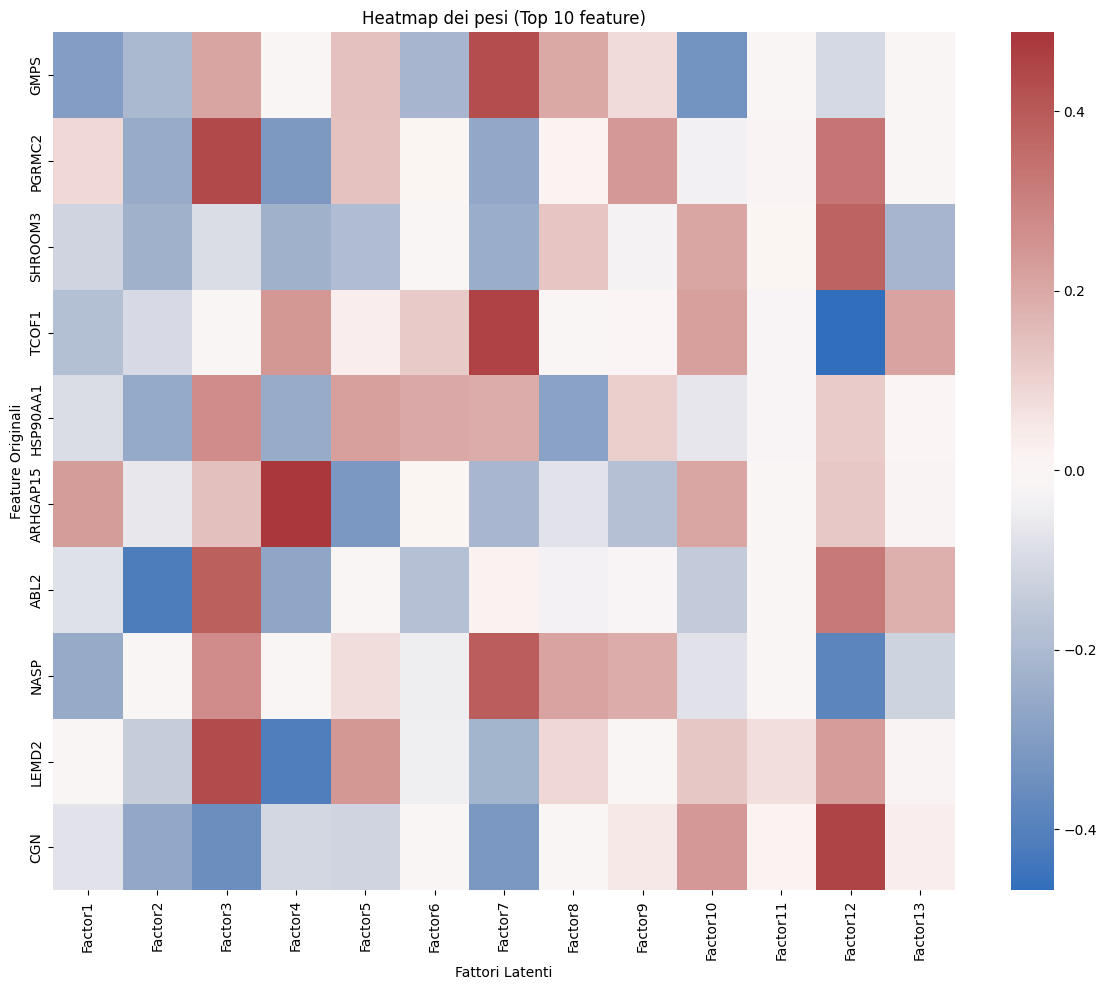


=== Heatmap dei pesi: proteome ===


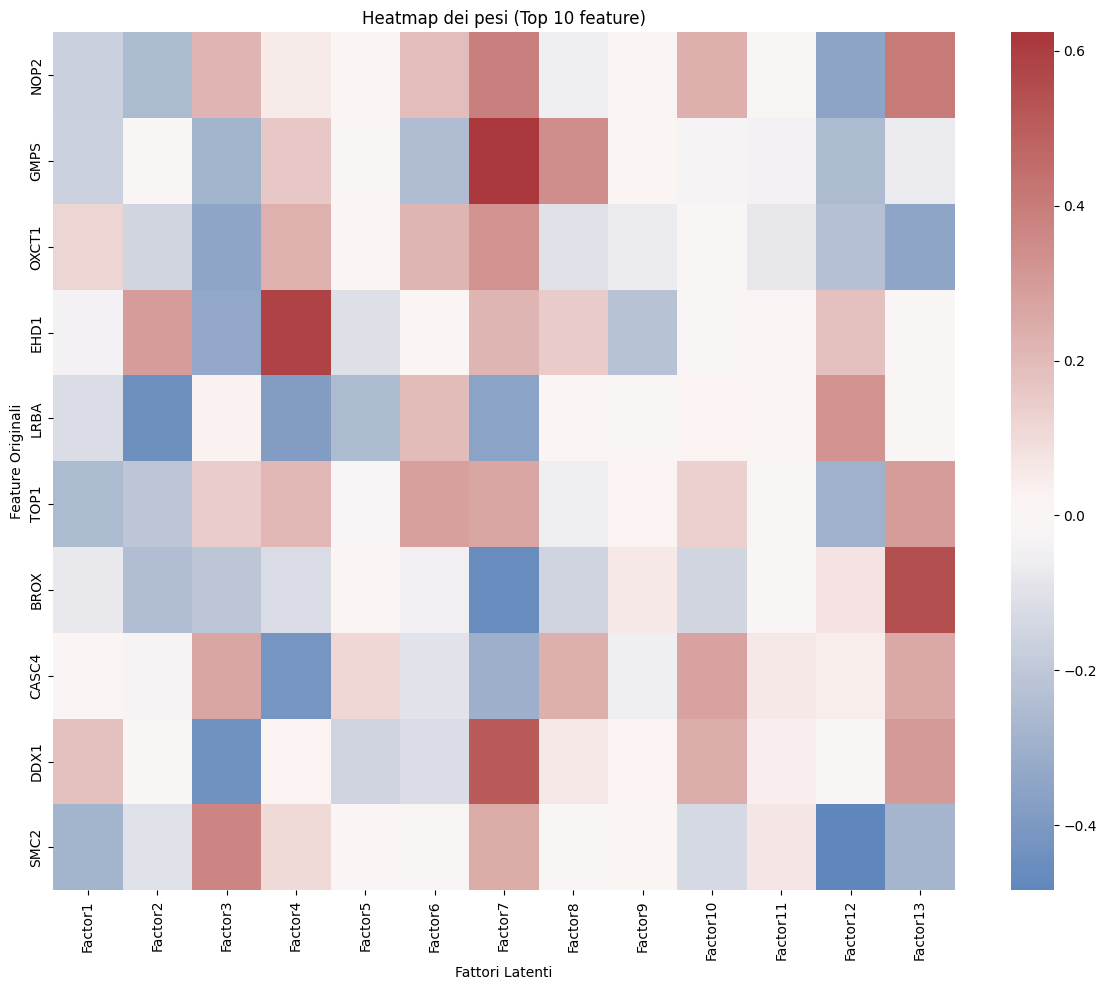


=== Heatmap dei pesi: SCNA ===


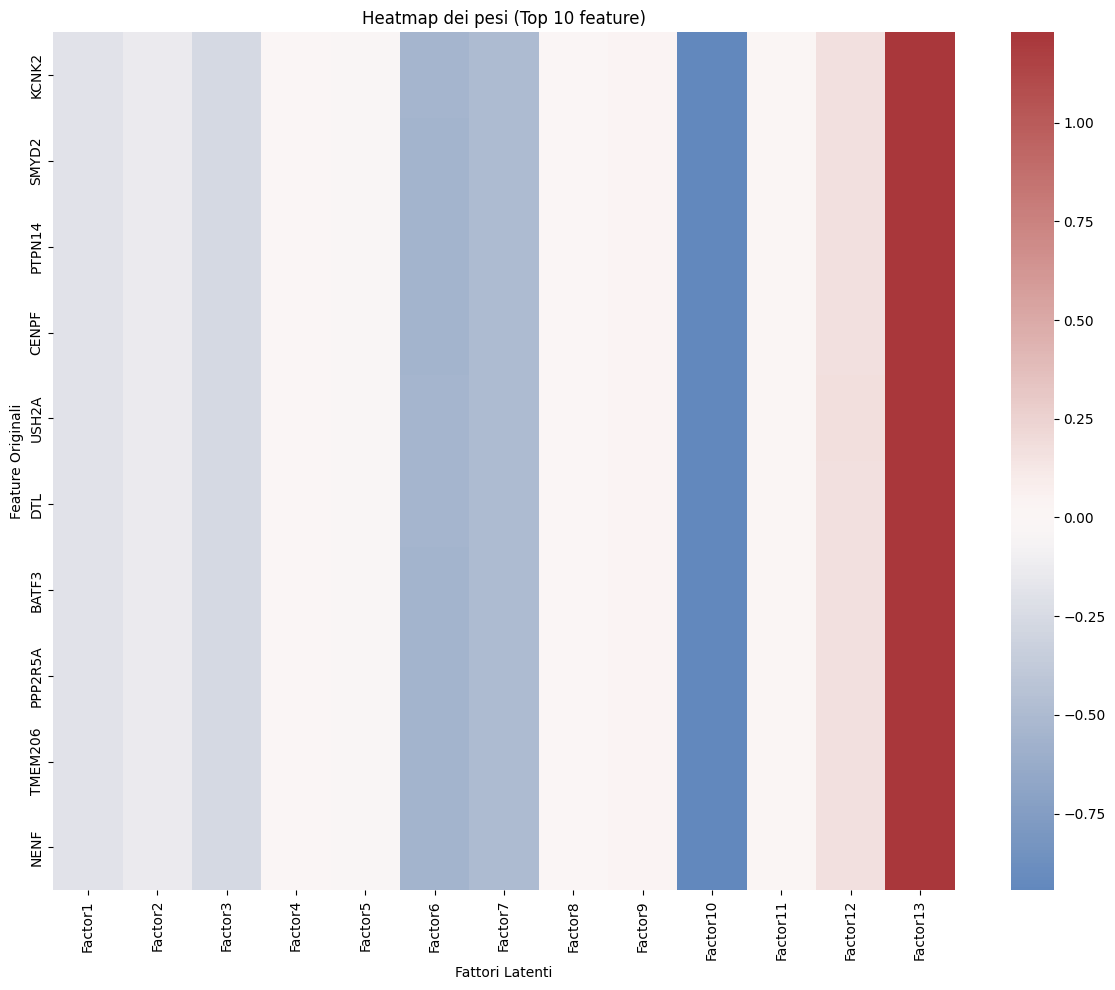

In [15]:
def plot_mofa_top_weights_heatmap(df_weights, top_n=10, drop_columns=None, annot=False, figsize=(12,10), view_name=""):

    # 1. Copia del dataframe
    df_plot = df_weights.copy()

    # 2. Rimuovi eventuali colonne testuali
    if drop_columns is not None:
        df_plot = df_plot.drop(columns=drop_columns, errors='ignore')

    # 3. Calcola “importanza” delle feature come somma valori assoluti dei pesi
    feature_importance = df_plot.abs().sum(axis=1)

    # 4. Seleziona le top N feature
    top_features = feature_importance.nlargest(top_n).index
    df_plot = df_plot.loc[top_features]

    # 5. Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(
        df_plot,
        cmap="vlag",      # blu = negativo, rosso = positivo
        center=0,
        annot=annot,
        yticklabels=True
    )
    plt.title("Heatmap dei pesi (Top {} feature)".format(top_n))
    plt.xlabel("Fattori Latenti")
    plt.ylabel("Feature Originali")
    plt.tight_layout()
    plt.savefig(f'../img/MOFA_{view_name}_W_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

for view_name, df_weights in weights_per_view.items():
    print(f"\n=== Heatmap dei pesi: {view_name} ===")
    plot_mofa_top_weights_heatmap(
        df_weights,
        top_n=10,
        view_name=view_name
    )


In [ ]:
# ANALISI DEI DRIVER OMICI PER OGNI FATTORE LATENTI
# Per ogni fattore latente, identifichiamo le feature con i pesi più alti e testiamo se i factor scores sono significativamente diversi tra pazienti con alta vs bassa espressione di quella feature. Usiamo il test di Wilcoxon (Mann-Whitney U) per confrontare i due gruppi.

def analyze_omic_drivers(df_factors, dict_weights, views, top_n=10):
    """
    df_factors: DataFrame con i factor scores (pazienti x fattori)
    dict_weights: Dizionario {nome_vista: DataFrame pesi (feature x fattori)}
    dict_views: Dizionario {nome_vista: DataFrame dati originali (pazienti x feature)}
    top_n: Numero di top feature da testare per ogni fattore
    """
    results = []

    for factor in df_factors.columns:
        for view_name, df_weights in dict_weights.items():
            # 1. Identifica le top feature per questo fattore nella vista corrente
            # Usiamo il valore assoluto perché pesi molto negativi sono altrettanto importanti
            top_features = df_weights[factor].abs().sort_values(ascending=False).head(top_n).index
            
            for feature in top_features:
                # Recuperiamo i dati di espressione per questa feature e i factor scores
                expression = views[view_name][feature] # valori di una feature (vettore colonna Nx1) all'interno della vista in esame
                factor_scores = df_factors[factor] # vettore colonna (Nx1) con valore numerico del fattore in esame
                
                # Creiamo un set di dati pulito dai NaN
                mask = expression.notna() & factor_scores.notna() # array booleano per filtrare solo i pazienti con dati validi sia per l'espressione che per i factor scores
                exp_clean = expression[mask]
                fs_clean = factor_scores[mask]
                
                if len(exp_clean) < 10: continue # Salta se troppi pochi dati
                
                # 2. Discretizzazione: Dividiamo i pazienti in "High" e "Low" sulla base del valore mediano del fattore
                median_val = exp_clean.median()
                group_high = fs_clean[exp_clean > median_val]
                group_low = fs_clean[exp_clean <= median_val]
                
                # 3. Test di Wilcoxon (Mann-Whitney U)
                # Verifica se i factor scores sono diversi tra chi ha espressione alta vs bassa della feature
                if len(group_high) > 0 and len(group_low) > 0:
                    stat, pval = mannwhitneyu(group_high, group_low, alternative='two-sided')
                    
                    results.append({
                        'Factor': factor,
                        'View': view_name,
                        'Feature': feature,
                        'Weight': df_weights.loc[feature, factor],
                        'Wilcoxon_p-value': pval
                    })

    # Creazione DataFrame e correzione p-value (FDR)
    df_res = pd.DataFrame(results)
    if not df_res.empty:
        df_res['p-adj'] = multipletests(df_res['Wilcoxon_p-value'], method='fdr_bh')[1]
    
    return df_res.sort_values(by=['Factor', 'p-adj'])

df_drivers = analyze_omic_drivers(df_factors, weights_per_view, views, top_n=10)
df_drivers.to_excel('./exported_data/MOFA_drivers_analysis.xlsx', sheet_name='Drivers')
df_drivers.head()

,Factor,View,Feature,Weight,Wilcoxon_p-value,p-adj
18,Factor1,miRNA,hsa-miR-222-3p,-0.230826,0.000077,0.059914
14,Factor1,miRNA,hsa-miR-221-3p,-0.253421,0.013230,0.495081
45,Factor1,proteome,TCEAL3,0.379767,0.010750,0.495081
49,Factor1,proteome,CGNL1,0.374430,0.013071,0.495081
15,Factor1,miRNA,hsa-miR-99a-3p,0.244521,0.016202,0.526560


1. Uso di Wilcoxon su variabili continue: Poiché Wilcoxon confronta distribuzioni tra gruppi, abbiamo creato i gruppi "High" e "Low" basandoci sulla variabile continua (il gene). Se la distribuzione del fattore nel gruppo "High" è diversa da quella nel gruppo "Low", allora il fattore e il gene sono "allineati".

2. Top Weights: Il codice non guarda tutto il dataset (sarebbero troppi test), ma seleziona prima i candidati più probabili (quelli che MOFA ha già indicato come importanti tramite i pesi).

In [ ]:
from scipy.stats import chi2_contingency

def analyze_clinical_categorical(df_factors, df_clinical):
    """
    df_factors: DataFrame (pazienti x fattori)
    df_clinical: DataFrame (pazienti x variabili cliniche categoriche)
    """
    results = []

    # Selezioniamo solo le variabili categoriche (object o category) 
    # o numeriche con pochi valori unici (es. 0, 1)
    cat_vars = df_clinical.select_dtypes(exclude=[np.number]).columns.tolist()
    # Aggiungiamo eventuali variabili numeriche discrete (es. Stadio codificato 1, 2, 3)
    for col in df_clinical.select_dtypes(include=[np.number]).columns:
        if df_clinical[col].nunique() <= 5: 
            cat_vars.append(col)

    for factor in df_factors.columns:
        # 1. DISCRETIZZAZIONE DEL FATTORE
        # Dividiamo i pazienti in "High" e "Low" in base alla mediana del fattore
        factor_series = df_factors[factor]
        median_val = factor_series.median()
        factor_discrete = np.where(factor_series > median_val, 'High', 'Low')
        
        df_temp = pd.DataFrame({
            'Factor_Group': factor_discrete,
            'index': df_factors.index
        }).set_index('index')

        for var in cat_vars:
            # Uniamo i dati e rimuoviamo i NaN
            combined = pd.concat([df_temp['Factor_Group'], df_clinical[var]], axis=1).dropna()
            
            if combined.empty: continue

            # 2. CREAZIONE DELLA TABELLA DI CONTINGENZA
            # Conta quanti pazienti ci sono per ogni incrocio (es. High-Factor & Stadio_II)
            contingency_table = pd.crosstab(combined['Factor_Group'], combined[var])
            
            # 3. TEST DEL CHI-QUADRATO
            # Verifichiamo se la distribuzione del fattore è indipendente dalla variabile clinica
            try:
                chi2, pval, dof, expected = chi2_contingency(contingency_table)
                
                results.append({
                    'Factor': factor,
                    'Clinical_Variable': var,
                    'Chi2_Stat': chi2,
                    'p-value': pval,
                    'n_patients': len(combined)
                })
            except ValueError:
                # Salta se la tabella è troppo piccola o vuota
                continue

    # Creazione DataFrame e correzione p-value (FDR)
    df_res = pd.DataFrame(results)
    if not df_res.empty:
        df_res['p-adj'] = multipletests(df_res['p-value'], method='fdr_bh')[1]
    
    return df_res.sort_values(by='p-adj')

# Esempio d'uso:
df_clinical_res = analyze_clinical_categorical(df_factors, clinical_df)
df_clinical_res.to_excel('./exported_data/MOFA_clinical_analysis.xlsx', sheet_name='Clinical_Association')
df_clinical_res.head()

,Factor,Clinical_Variable,Chi2_Stat,p-value,n_patients,p-adj
15,Factor1,alcohol_consumption,31.063231,0.000003,135,0.000773
3,Factor1,participant_country,43.815628,0.000008,137,0.001018
73,Factor4,tumor_stage_pathological,15.583506,0.008139,131,0.705421
17,Factor1,vital_status,4.742749,0.029422,133,0.804292
36,Factor2,tobacco_smoking_history,10.825703,0.054947,135,0.804292


In [ ]:
def synthesize_factor_meanings(df_omic_drivers, df_clinical_res, p_threshold=0.05):
    """
    df_omic_drivers: output del test di Wilcoxon sulle omiche
    df_clinical_res: output del test Chi-quadrato sulla clinica
    """
    summary = []

    # Otteniamo tutti i fattori unici presenti in entrambi i risultati
    all_factors = sorted(set(df_omic_drivers['Factor']) | set(df_clinical_res['Factor']))

    for factor in all_factors:
        # 1. Recupera Driver Omici significativi
        omic_sig = df_omic_drivers[
            (df_omic_drivers['Factor'] == factor) & 
            (df_omic_drivers['p-adj'] < p_threshold)
        ].sort_values(by='Weight', key=abs, ascending=False)
        
        top_genes = omic_sig['Feature'].head(5).tolist()
        views_involved = omic_sig['View'].unique().tolist()

        # 2. Recupera Associazioni Cliniche significative
        clin_sig = df_clinical_res[
            (df_clinical_res['Factor'] == factor) & 
            (df_clinical_res['p-adj'] < p_threshold)
        ].sort_values(by='p-adj')
        
        top_clin = clin_sig['Clinical_Variable'].head(3).tolist()

        # 3. Creazione del "Significato Reale" (Logica di sintesi)
        omic_desc = ", ".join(top_genes) if top_genes else "Nessun driver forte"
        clin_desc = ", ".join(top_clin) if top_clin else "Nessuna associazione clinica"
        
        meaning = "Indefinito"
        if top_genes and top_clin:
            meaning = f"Asse biologico guidato da {omic_desc} con impatto su {clin_desc}"
        elif top_genes:
            meaning = f"Processo biologico coinvolgente {omic_desc} (clinicamente silente)"
        elif top_clin:
            meaning = f"Segnale clinico legato a {clin_desc} (driver molecolari non chiari)"

        summary.append({
            'Fattore': factor,
            'Driver Molecolari (Top 5)': omic_desc,
            'Viste Coinvolte': ", ".join(views_involved),
            'Associazioni Cliniche': clin_desc,
            'Sintesi Interpretativa': meaning
        })

    return pd.DataFrame(summary)

# Esempio d'uso:
df_final_summary = synthesize_factor_meanings(df_drivers, df_clinical_res, p_threshold=0.4)
df_final_summary.to_excel('./exported_data/MOFA_final_summary.xlsx', sheet_name='Final_Summary')
df_final_summary

,Fattore,Driver Molecolari (Top 5),Viste Coinvolte,Associazioni Cliniche,Sintesi Interpretativa
0,Factor1,hsa-miR-222-3p,miRNA,"alcohol_consumption, participant_country",Asse biologico guidato da hsa-miR-222-3p con i...
1,Factor10,"hsa-miR-629-5p, hsa-miR-346",miRNA,Nessuna associazione clinica,Processo biologico coinvolgente hsa-miR-629-5p...
2,Factor11,PPIL2,mRNA,Nessuna associazione clinica,Processo biologico coinvolgente PPIL2 (clinica...
3,Factor12,Nessun driver forte,,Nessuna associazione clinica,Indefinito
4,Factor13,Nessun driver forte,,Nessuna associazione clinica,Indefinito
5,Factor2,Nessun driver forte,,Nessuna associazione clinica,Indefinito
6,Factor3,Nessun driver forte,,Nessuna associazione clinica,Indefinito
7,Factor4,hsa-miR-200a-3p,miRNA,Nessuna associazione clinica,Processo biologico coinvolgente hsa-miR-200a-3...
8,Factor5,Nessun driver forte,,Nessuna associazione clinica,Indefinito
9,Factor6,GAGE12I,mRNA,Nessuna associazione clinica,Processo biologico coinvolgente GAGE12I (clini...


DATA SAVING

In [19]:
os.makedirs("PDAC_DATA_MOFA_DATA", exist_ok=True)

# Salva df_factors
df_factors.to_csv("PDAC_DATA_MOFA_DATA/df_factors.csv", index=True)

# Salva le matrici dei pesi per ogni vista
for view_name, df_w in weights_per_view.items():
    df_w.to_csv(f"PDAC_DATA_MOFA_DATA/weights_{view_name}.csv", index=True)